# Baseline models
* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 722, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 722 (delta 9), reused 20 (delta 9), pack-reused 693 (from 2)
Receiving objects: 100% (722/722), 23.33 MiB | 19.23 MiB/s, done.
Resolving deltas: 100% (352/352), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, PREDICTION_THRESHOLD, BASELINE_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels = val_df['pathology'].to_numpy()

In [ ]:
# CSV Files to store all baseline results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/baseline_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE = len(train_df)
# No. of training samples in training dataframe for class weight
TOTAL_TRAINING_SAMPLES = len(train_df)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_df, CLASSES, TOTAL_TRAINING_SAMPLES)

In [ ]:
# Baseline (resizing + model-specific normalization) preprocessing
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

### tf.data Dataset Preparation for Baseline

In [ ]:
# Generate training and validation datasets for baseline
train_dataset = dataset_preparation(train_df, baseline_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset = dataset_preparation(val_df, baseline_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

## VGG16

In [ ]:
# Select the VGG16 model
vgg16_model = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16, _, _ = train_selected_model(vgg16_model, train_dataset, val_dataset, BASELINE_EPOCHS, early_stopping, class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 515ms/step - auc: 0.4429 - loss: 0.9144 - precision: 0.4611 - recall: 0.4524 - val_auc: 0.4834 - val_loss: 0.6751 - val_precision: 0.5208 - val_recall: 0.3261
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 508ms/step - auc: 0.4669 - loss: 0.7890 - precision: 0.4902 - recall: 0.4447 - val_auc: 0.5076 - val_loss: 0.6483 - val_precision: 0.5496 - val_recall: 0.3130
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 505ms/step - auc: 0.4946 - loss: 0.7384 - precision: 0.5275 - recall: 0.4768 - val_auc: 0.5363 - val_loss: 0.6249 - val_precision: 0.5952 - val_recall: 0.3261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 501ms/step - auc: 0.5047 - loss: 0.7207 - precision: 0.5201 - recall: 0.4723 - val_auc: 0.5551 - val_loss: 0.6245 - val_precision: 0.5723 - val_recall: 0.3957
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 511ms/step - auc: 0.5131 - loss: 0.6978 - precision: 0.5561 - recall: 0.4768 - val_auc: 0.5605 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, _, metrics_dict_vgg16, _ = generate_predictions_and_evaluations(vgg16, val_dataset, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - auc: 0.5791 - loss: 0.5748 - precision: 0.6907 - recall: 0.2913


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='Baseline',
    eval_metrics=metrics_dict_vgg16,
    experiment_type='baseline'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_results_df)

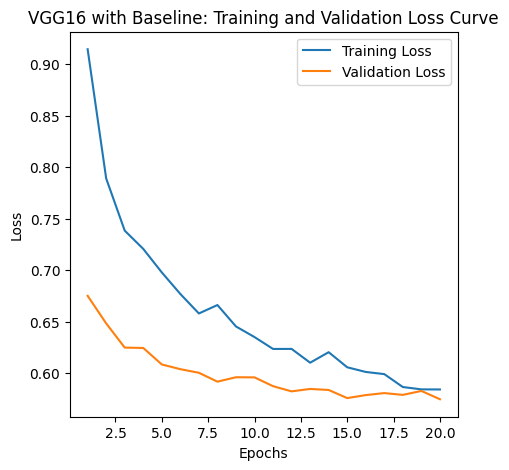

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16.history, 'VGG16', 'Baseline')

## ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50, _, _ = train_selected_model(resnet50_model, train_dataset, val_dataset, BASELINE_EPOCHS, early_stopping, class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 543ms/step - auc: 0.4672 - loss: 0.7131 - precision: 0.4861 - recall: 0.4060 - val_auc: 0.5871 - val_loss: 0.5869 - val_precision: 0.7719 - val_recall: 0.1913
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 508ms/step - auc: 0.5540 - loss: 0.6362 - precision: 0.5821 - recall: 0.4668 - val_auc: 0.6104 - val_loss: 0.5785 - val_precision: 0.6571 - val_recall: 0.4000
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 509ms/step - auc: 0.5706 - loss: 0.6246 - precision: 0.6075 - recall: 0.4469 - val_auc: 0.6177 - val_loss: 0.5956 - val_precision: 0.6048 - val_recall: 0.5522
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 493ms/step - auc: 0.5833 - loss: 0.6027 - precision: 0.5968 - recall: 0.4535 - val_auc: 0.6167 - val_loss: 0.5934 - val_precision: 0.6028 - val_recall: 0.5609
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 490ms/step - auc: 0.6107 - loss: 0.5945 - precision: 0.6345 - recall: 0.5088 - val_auc: 0.6316 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, _, metrics_dict_resnet50, _ = generate_predictions_and_evaluations(resnet50, val_dataset, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - auc: 0.6372 - loss: 0.5504 - precision: 0.7273 - recall: 0.4174


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Baseline',
    eval_metrics=metrics_dict_resnet50,
    experiment_type='baseline'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_results_df)

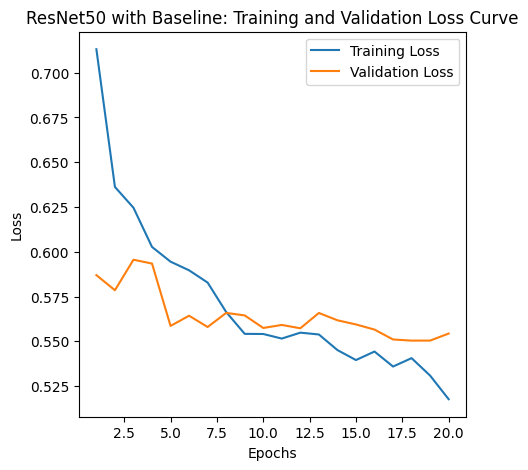

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50.history, 'ResNet50', 'Baseline')

## DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121, _, _ = train_selected_model(densenet121_model, train_dataset, val_dataset, BASELINE_EPOCHS, early_stopping, class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 61s 590ms/step - auc: 0.4196 - loss: 1.3139 - precision: 0.4198 - recall: 0.4259 - val_auc: 0.4849 - val_loss: 0.8107 - val_precision: 0.5021 - val_recall: 0.5261
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 516ms/step - auc: 0.4574 - loss: 0.9946 - precision: 0.4831 - recall: 0.4436 - val_auc: 0.4674 - val_loss: 0.6916 - val_precision: 0.6829 - val_recall: 0.1217
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 517ms/step - auc: 0.4647 - loss: 0.9311 - precision: 0.4910 - recall: 0.4248 - val_auc: 0.5205 - val_loss: 0.7199 - val_precision: 0.5271 - val_recall: 0.4652
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 516ms/step - auc: 0.4819 - loss: 0.8284 - precision: 0.5235 - recall: 0.4558 - val_auc: 0.5093 - val_loss: 0.6916 - val_precision: 0.5486 - val_recall: 0.4174
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 508ms/step - auc: 0.4860 - loss: 0.7482 - precision: 0.5201 - recall: 0.4292 - val_auc: 0.4493 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, _, metrics_dict_densenet121, _ = generate_predictions_and_evaluations(densenet121, val_dataset, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 444ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - auc: 0.4849 - loss: 0.8107 - precision: 0.5021 - recall: 0.5261


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Baseline',
    eval_metrics=metrics_dict_densenet121,
    experiment_type='baseline'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_results_df)

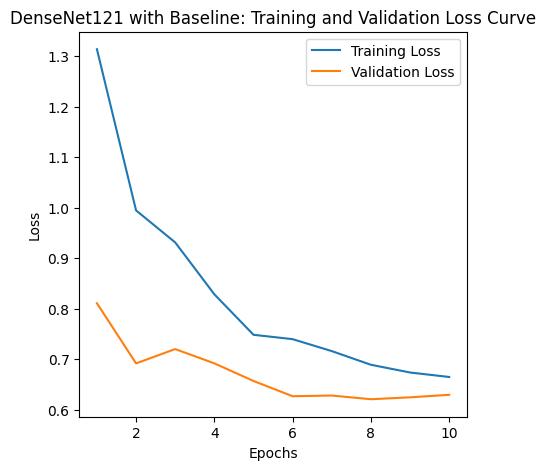

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121.history, 'DenseNet121', 'Baseline')

## MobileNetv2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2, _, _ = train_selected_model(mobilenetv2_model, train_dataset, val_dataset, BASELINE_EPOCHS, early_stopping, class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 456ms/step - auc: 0.4700 - loss: 0.7029 - precision: 0.5056 - recall: 0.2998 - val_auc: 0.5135 - val_loss: 0.6940 - val_precision: 0.5401 - val_recall: 0.3217
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 430ms/step - auc: 0.4887 - loss: 0.6882 - precision: 0.5081 - recall: 0.3142 - val_auc: 0.5190 - val_loss: 0.6666 - val_precision: 0.5882 - val_recall: 0.2174
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 422ms/step - auc: 0.5050 - loss: 0.6660 - precision: 0.5385 - recall: 0.3175 - val_auc: 0.5370 - val_loss: 0.6542 - val_precision: 0.6667 - val_recall: 0.1739
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 426ms/step - auc: 0.5045 - loss: 0.6649 - precision: 0.5358 - recall: 0.3230 - val_auc: 0.5304 - val_loss: 0.7162 - val_precision: 0.4857 - val_recall: 0.5913
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 421ms/step - auc: 0.5235 - loss: 0.6521 - precision: 0.5531 - recall: 0.3285 - val_auc: 0.5198 - val_loss

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, _, metrics_dict_mobilenetv2, _ = generate_predictions_and_evaluations(mobilenetv2, val_dataset, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - auc: 0.5135 - loss: 0.6940 - precision: 0.5401 - recall: 0.3217


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Baseline',
    eval_metrics=metrics_dict_mobilenetv2,
    experiment_type='baseline'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_results_df)

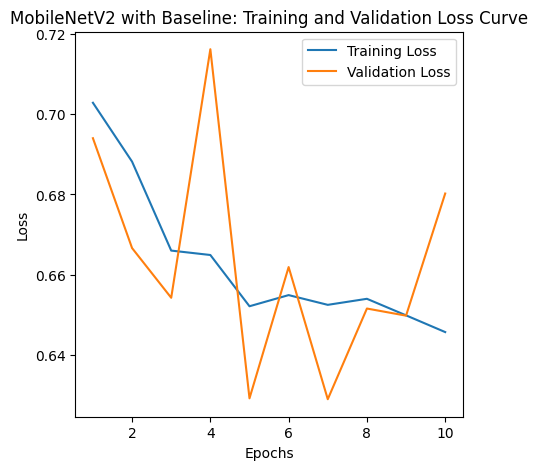

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2.history, 'MobileNetV2', 'Baseline')

## EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0, _, _ = train_selected_model(efficientnetb0_model, train_dataset, val_dataset, BASELINE_EPOCHS, early_stopping, class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 481ms/step - auc: 0.4901 - loss: 0.6670 - precision: 0.5599 - recall: 0.2223 - val_auc: 0.5927 - val_loss: 0.6092 - val_precision: 0.7313 - val_recall: 0.2130
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 444ms/step - auc: 0.5779 - loss: 0.6223 - precision: 0.6226 - recall: 0.3595 - val_auc: 0.6062 - val_loss: 0.5900 - val_precision: 0.7903 - val_recall: 0.2130
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 439ms/step - auc: 0.5952 - loss: 0.6148 - precision: 0.6402 - recall: 0.3838 - val_auc: 0.6104 - val_loss: 0.6052 - val_precision: 0.6538 - val_recall: 0.4435
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 441ms/step - auc: 0.6072 - loss: 0.6014 - precision: 0.6585 - recall: 0.3883 - val_auc: 0.6150 - val_loss: 0.5883 - val_precision: 0.6891 - val_recall: 0.3565
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 439ms/step - auc: 0.6008 - loss: 0.6050 - precision: 0.6332 - recall: 0.3838 - val_auc: 0.6212 - val_lo

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, _, metrics_dict_efficientnetb0, _ = generate_predictions_and_evaluations(efficientnetb0, val_dataset, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - auc: 0.5927 - loss: 0.6092 - precision: 0.7313 - recall: 0.2130


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Baseline',
    eval_metrics=metrics_dict_efficientnetb0,
    experiment_type='baseline'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_results_df)

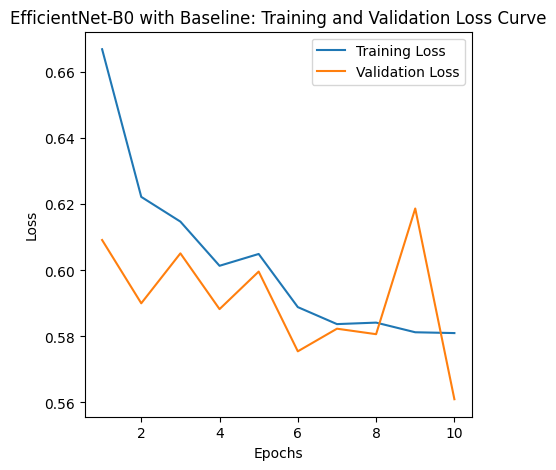

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0.history, 'EfficientNet-B0', 'Baseline')